- Here we analyze how the structure function changes when modifying the 'Turbustat' versions for sysnthetic:
    - two-dimensional (https://turbustat.readthedocs.io/en/latest/api/turbustat.simulator.make_extended.html#turbustat.simulator.make_extended)
    - and three-dimensional fields (https://turbustat.readthedocs.io/en/latest/api/turbustat.simulator.make_3dfield.html#make-3dfield)
- Also, the recover the turbulent paramters throught a fit.


In [1]:
import time
start_time=time.time()

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from spectral_cube import SpectralCube
from turbustat.simulator import make_ppv
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
from skimage.util import random_noise
import corner

i

# Add path to py_modules 

sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

from turb_utils import make_extended, make_3dfield
import strucfunc
import bfunc
import bplot

In [57]:
import ci_results_compiler
import fit_structure_function

In [37]:
# Physical parameters

N     = 512
ra    = N / 16 # Artificial correlation length
m_obs = 1.0    # The projected slope of the structure function we measure in nature
m2D   = 0.85   # for recovering m as 1.00 in the projected field (k = 2D + m2D) non emissivity fluctuation case
m3D_1 = 0.30   # for recovering m as 1.00 in the projected field (k = 3D + m3D) light fluctuations
m3D_2 = 0.55   # for recovering m as 1.00 in the projected field (k = 3D + m3D) heavy fluctuations

# Modification

``` python
    if ellip < 1:
        # Apply a rotation and scale the x-axis (ellip).
        costheta = np.cos(theta)
        sintheta = np.sin(theta)

        xprime = ellip * (xx * costheta - yy * sintheta)
        yprime = xx * sintheta + yy * costheta

        rr2 = xprime ** 2 + yprime ** 2

        rr = rr2 ** 0.5
        # Also save circular version to use with correlation_length <-----------
        rcirc = np.hypot(xx, yy)   <-----------
        rcirc[rcirc == 0.0] = np.nan  <-----------
    else:
        # Circular whenever ellip == 1
        rr = (xx ** 2 + yy ** 2) ** 0.5

    # flag out the bad point to avoid warnings
    rr[rr == 0] = np.nan

    if correlation_length is not None:     <-----------
        # Taper the power spectrum at large separations (low spatial   <-----------
        # frequencies) so that the field is uncorrelated at the <-----------
        # largest scales. <-----------
        #
        # rcirc is spatial frequency: 1 / r, measured in pixels <-----------
        output *= np.exp(-1.0 / (2 * np.pi * rcirc * correlation_length)) <-----------
```


$$e^{-\dfrac{1}{2 \pi k r_0}}$$


# Fake velocity cubes velocity and emissivity


- Generate simulated emissivity and velocity cubes
- Integrate them to get simulated intensity, velocity (and sigma) maps

In [15]:
## Sie E = 0

## Sie E = 1

In [4]:
sig_E = 1 

In [5]:
# Non-Tapered
## Emissivity fluctuations


density = make_3dfield(N, 
    powerlaw            = 3.0 + m3D_1, 
#    correlation_length  = r0,  
    amp                 = 1.0,
    ellip               = 0.5,
    theta               = 45,
    randomseed          = 1939_05_01) * u.cm**-3 

density = (density-density.mean())/density.std()

emissivity = np.exp(sig_E * density)* u.cm**-3


# Velocity fluctuations

velocity = make_3dfield(N,
    powerlaw           =3.0 + m3D_1,
#    correlation_length = r0,  
    ellip              = 0.5,
    theta              = 45,
    randomseed         = 1894_04_25)* u.km / u.s  

# Making PPV cube

cube_hdu = make_ppv(velocity, emissivity, los_axis=0,
                    T=10000 * u.K, chan_width=0.5 * u.km / u.s,
                    v_min=-20 * u.km / u.s,
                    v_max=20 * u.km / u.s)  

cube0 = SpectralCube.read(cube_hdu)  

In [7]:
# Tapered
## Emissivity fluctuations

density = make_3dfield(N, 
    powerlaw            = 3.0 + m3D_1, 
    correlation_length  = ra,  
    amp                 = 1.0,
    ellip               = 0.5,
    theta               = 45,
    randomseed          = 1939_05_01) * u.cm**-3 

density = (density-density.mean())/density.std()

emissivity = np.exp(sig_E * density)* u.cm**-3


# Velocity fluctuations

velocity = make_3dfield(N,
    powerlaw           =3.0 + m3D_1,
    correlation_length = ra,  
    ellip              = 0.5,
    theta              = 45,
    randomseed         = 1894_04_25)* u.km / u.s   

# Making PPV cube

cube_hdu = make_ppv(velocity, emissivity, los_axis=0,
                    T=10000 * u.K, chan_width=0.5 * u.km / u.s,
                    v_min=-20 * u.km / u.s,
                    v_max=20 * u.km / u.s)  

cube = SpectralCube.read(cube_hdu)  

In [8]:
vmap_ = cube.moment1().value
vmap0_ = cube0.moment1().value

signorm_ = vmap_.std()
vmap_ /= signorm_

signorm0_ = vmap0_.std()
vmap0_ /= signorm0_

print(signorm_, signorm0_)

0.1757869623110296 0.39981058410470105


<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_18592\1423005607.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 1.0, '3D Non Tapered')

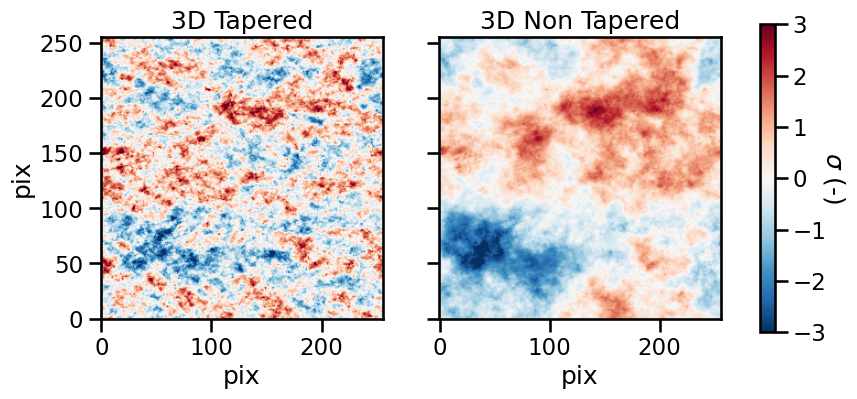

In [51]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", vmin=-3, vmax=3, cmap="RdBu_r")
im = ax.imshow(vmap_, **imshow_kwds)
im = axx.imshow(vmap0_, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax, axx])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)

ax.set_xlabel("pix")
ax.set_ylabel("pix")
axx.set_xlabel("pix")

ax.set_title("3D Tapered")
axx.set_title("3D Non Tapered")

# Structure Function

In [18]:
sf_ = strucfunc.strucfunc_numba_parallel(vmap_, dlogr=0.05)
sf0_ = strucfunc.strucfunc_numba_parallel(vmap0_, dlogr=0.05)

C:\Users\ZAINTEL2\Dropbox\GitHub\fake_maps\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\fake_maps\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


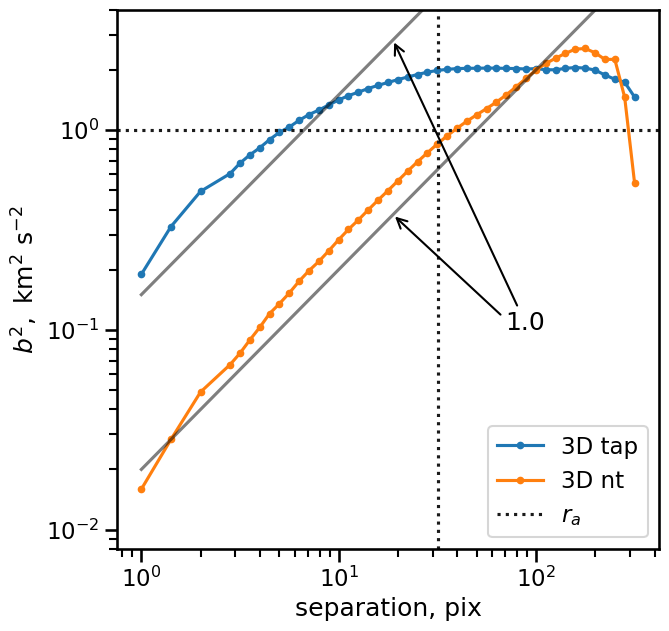

In [47]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(r_, B_, marker=".", label = '3D tap')
ax.plot(r_, B0_, marker=".", label = '3D nt')

ax.axhline(1.0, color="k", linestyle="dotted")
ax.axvline(ra, color="k", linestyle="dotted", label = r'$r_a$')
#ax.axvline(N / 2, color="k", linestyle="dashed")
#ax.axvline(N / 6, color="k", linestyle="dashed")

rgrid = np.logspace(0.0, 2.5)

for scale in 0.02, 0.15:
    ax.plot(rgrid, scale * rgrid ** (m_obs), color="black", alpha = 0.5)
    

ax.set(
    xlabel='separation, pix',
    ylabel=r'$b^2,\ \mathrm{km^2\ s^{-2}}$',
    xscale="log",
    yscale="log",
    ylim=[8e-3, 4],
)

ax.annotate(
    str(m_obs),           # text
    xy=(rgrid[len(rgrid)//2], 0.15 * rgrid[len(rgrid)//2] ** (m_obs)),            
    xytext=(70, 0.1),          # location of the text (data coords)
    arrowprops=dict(arrowstyle="->")  # arrow style
)

ax.annotate(
    ' ',           # text
    xy=(rgrid[len(rgrid)//2], 0.02 * rgrid[len(rgrid)//2] ** (m_obs)),            
    xytext=(70, 0.1),          # location of the text (data coords)
    arrowprops=dict(arrowstyle="->")  # arrow style
)

ax.legend()


# Confidence intervals

C:\Users\ZAINTEL2\anaconda3\Lib\site-packages\emcee\moves\red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


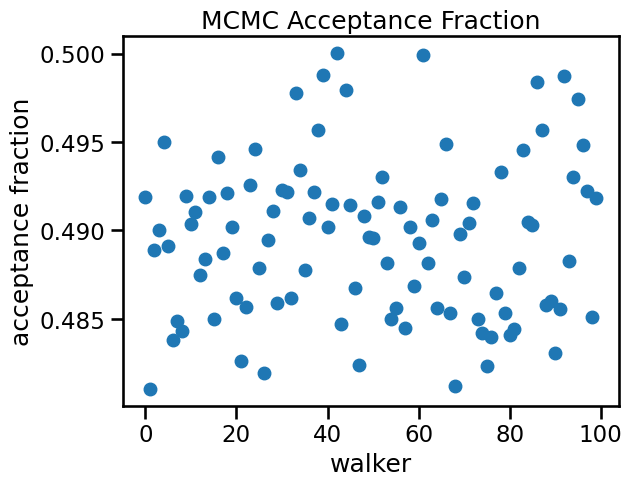

Autocorrelation time for the parameters:
----------------------------------------
r0 = 84.780
sig2 = 70.963
m = 71.106
s0 = 78.807
noise = 92.364


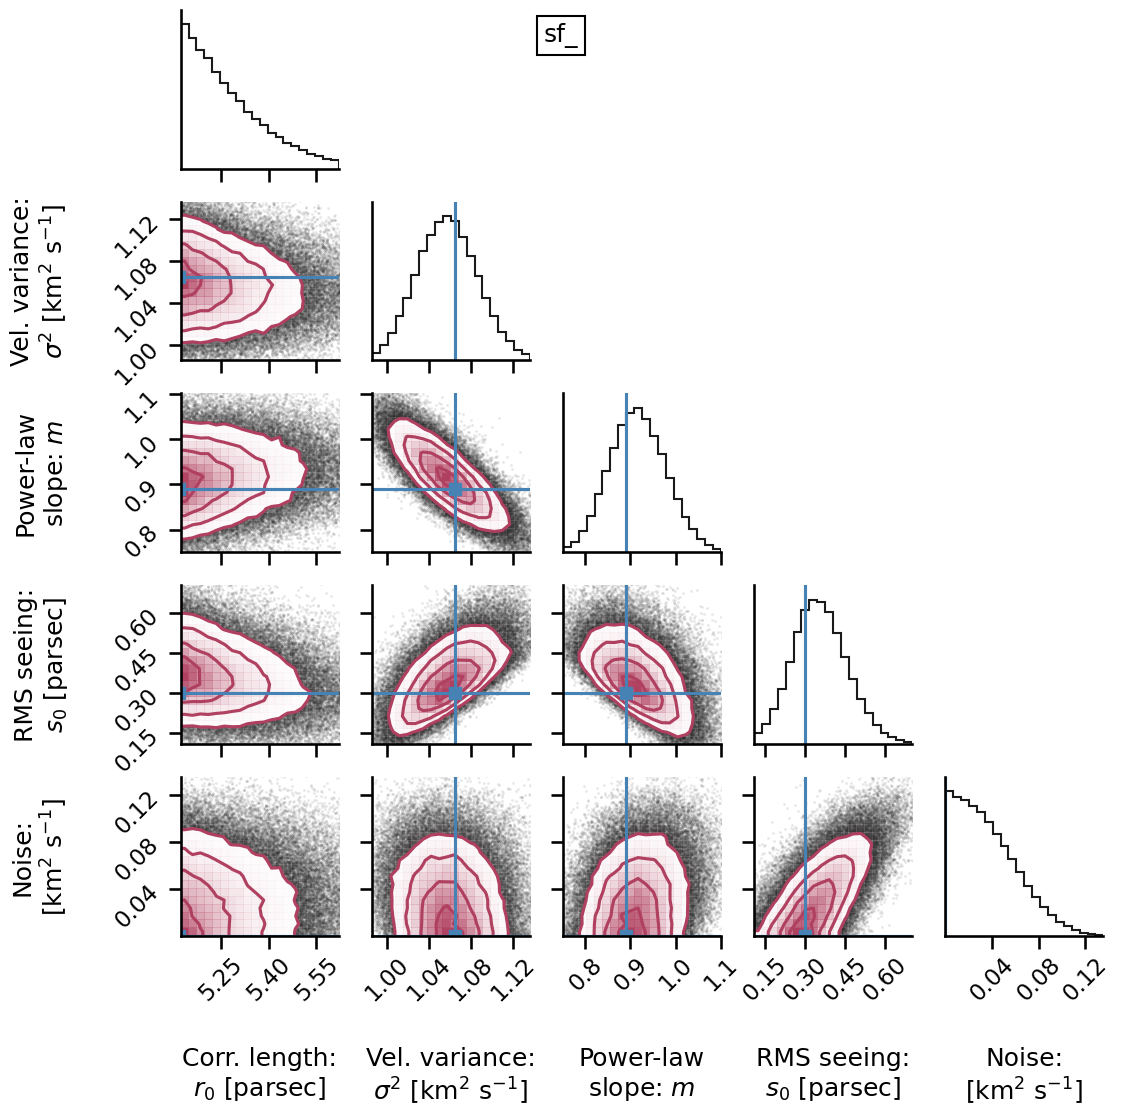

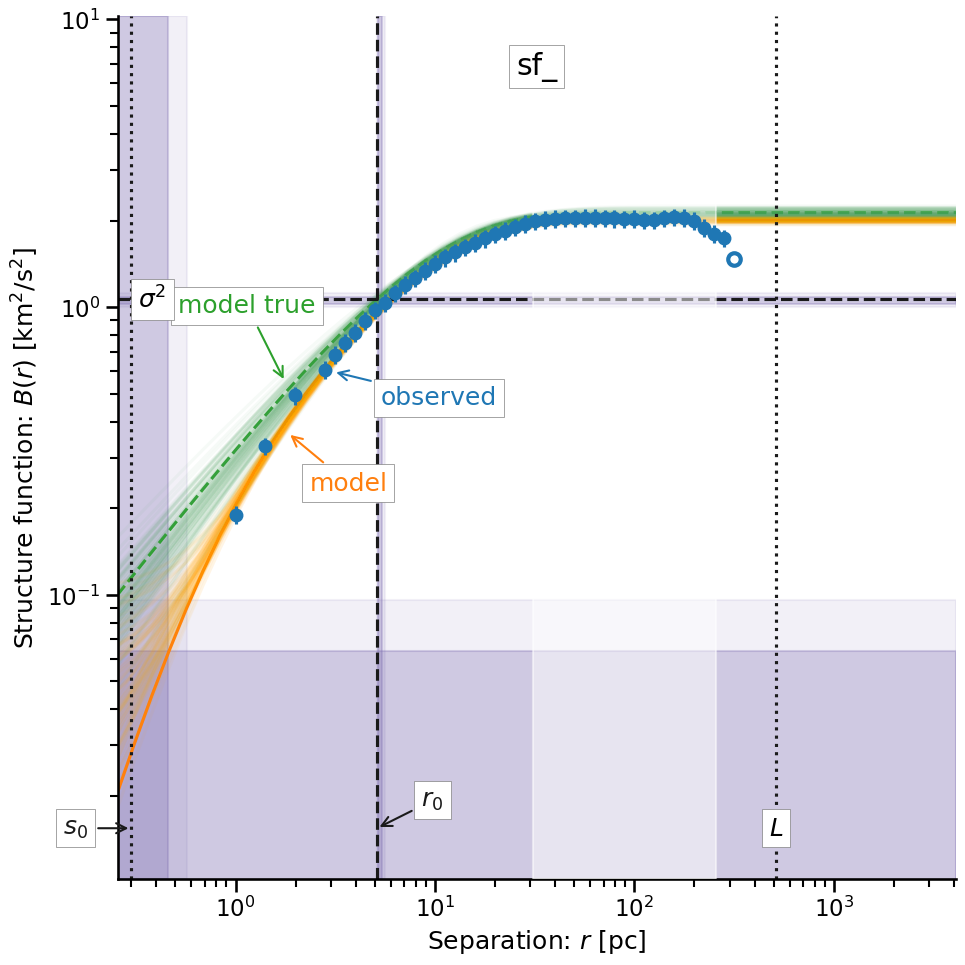

In [59]:
results_ = fit_structure_function.fit_structure_function(sf_, N, bfunc=bfunc, bplot=bplot, name = 'sf_', data = 'sf_')

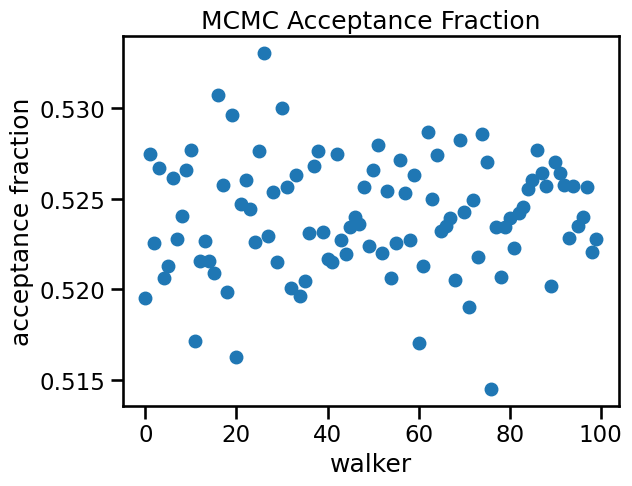

Autocorrelation time for the parameters:
----------------------------------------
r0 = 63.109
sig2 = 63.902
m = 62.883
s0 = 76.024
noise = 93.363


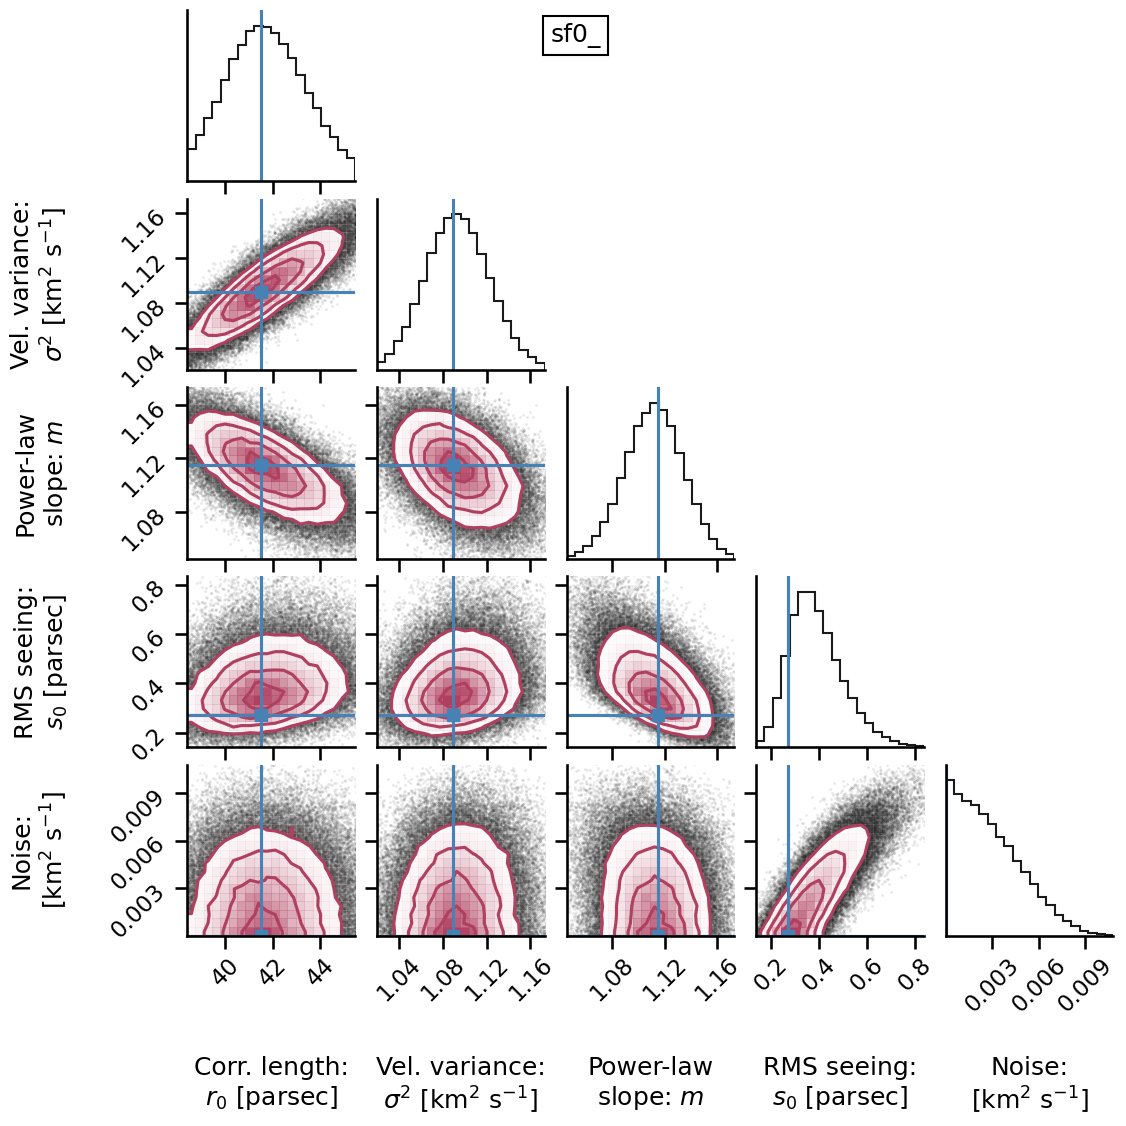

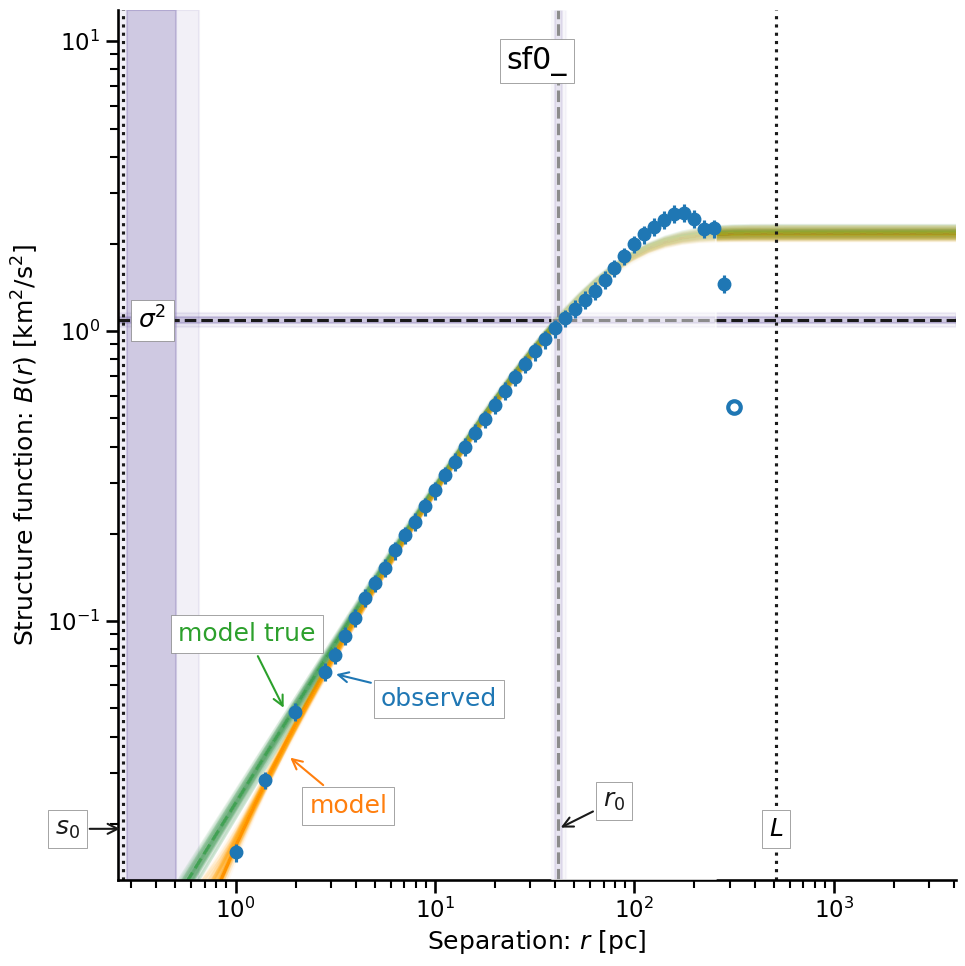

In [61]:
results0_ = fit_structure_function.fit_structure_function(sf0_, N, bfunc=bfunc, bplot=bplot, name = 'sf0_', data = 'sf0_')

In [ ]:
print("--- %s seconds ---" % (time.time()-start_time))